In [33]:
# !pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, classification_report, confusion_matrix, average_precision_score, precision_recall_curve, roc_auc_score, cohen_kappa_score
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.inspection import permutation_importance

## Load Data

In [35]:
# df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df = pd.read_csv('/kaggle/input/malnutrition/ch.csv')
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


### Train-test split

In [36]:
X = df.drop(columns=['malnurished'])
y = df['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [37]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 2828, 1: 2316})
After SMOTE:  Counter({1: 2828, 0: 2828})


# K-nearest Neighborhood

### Simple model

In [38]:
# recalls = []

# for k in range(1, 45):
#     knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
#     knn.fit(X_train, y_train)
#     y_pred = knn.predict(X_test)
#     recalls.append(recall_score(y_test, y_pred))

# plt.figure(figsize=(12, 4))
# plt.plot(range(1, 45), recalls, marker='o')
# plt.xlabel("Number of Neighbors (k)")
# plt.ylabel("Recall on Test Set")
# plt.title("Recall vs. n_neighbors on Test Set")
# plt.grid()
# plt.tight_layout()
# plt.show()

In [39]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(f'Classification Report: \n{classification_report(y_test, y_pred, digits = 3)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0      0.666     0.690     0.678       707
           1      0.604     0.577     0.590       579

    accuracy                          0.639      1286
   macro avg      0.635     0.634     0.634      1286
weighted avg      0.638     0.639     0.638      1286




In [40]:
y_probas = knn.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.6147573179071371


### With SMOTE

In [41]:
# recalls = []

# for k in range(1, 45):
#     knn_sm = KNeighborsClassifier(n_neighbors=k, weights='distance')
#     knn_sm.fit(X_train_sm, y_train_sm)
#     y_pred = knn_sm.predict(X_test)
#     recalls.append(recall_score(y_test, y_pred))

# plt.figure(figsize=(12, 4))
# plt.plot(range(1, 45), recalls, marker='o')
# plt.xlabel("Number of Neighbors (k)")
# plt.ylabel("Recall on Test Set")
# plt.title("Recall vs. n_neighbors on Test Set")
# plt.grid()
# plt.tight_layout()
# plt.show()

In [42]:
knn_sm = KNeighborsClassifier()
knn_sm.fit(X_train_sm, y_train_sm)
y_pred = knn_sm.predict(X_test)
print(f'Classification Report: \n{classification_report(y_test, y_pred, digits = 3)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0      0.673     0.608     0.639       707
           1      0.572     0.639     0.604       579

    accuracy                          0.622      1286
   macro avg      0.622     0.624     0.621      1286
weighted avg      0.627     0.622     0.623      1286




In [43]:
y_probas = knn_sm.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.6057696775677996


# Hyperparameter Tuning

In [55]:
params = {'n_neighbors':range(1, 36), 
          'weights':['uniform', 'distance'], 
          'metric': ['euclidean', 'manhattan', 'minkowski']}

grid_search = GridSearchCV(
    estimator=knn_sm,
    param_grid=params,
    cv=10,
    scoring='recall',
    verbose=1,
    n_jobs=2
)

grid_search.fit(X_train_sm, y_train_sm)

Fitting 10 folds for each of 210 candidates, totalling 2100 fits


GridSearchCV(cv=10, estimator=KNeighborsClassifier(), n_jobs=2,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': range(1, 36),
                         'weights': ['uniform', 'distance']},
             scoring='recall', verbose=1)

In [56]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 25, 'weights': 'distance'}
Best Cross-Validation Accuracy: 0.7270906949352179


In [57]:
knn_tune = grid_search.best_estimator_
y_pred = knn_tune.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.64      0.67       707
           1       0.61      0.68      0.64       579

    accuracy                           0.66      1286
   macro avg       0.66      0.66      0.66      1286
weighted avg       0.66      0.66      0.66      1286



In [58]:
y_probas_tune = knn_tune.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas_tune)}')

Average Precision: 0.631850977179204


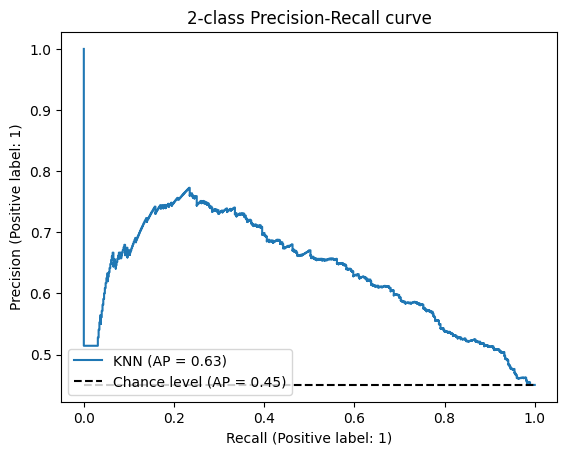

In [59]:
display = PrecisionRecallDisplay.from_estimator(
    knn_tune,   # trained model
    X_test,        # Test features
    y_test,        # True labels
    name="KNN",
    plot_chance_level=True,
)
display.ax_.set_title("2-class Precision-Recall curve")
plt.show()

In [60]:
auc = roc_auc_score(y_test, y_probas_tune)
print(f"AUC: {auc:.4f}")

AUC: 0.7062


### Confusion matrix

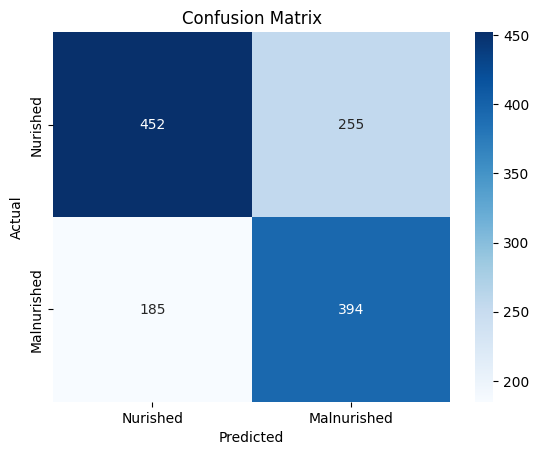

In [61]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature importance

In [51]:
# Compute permutation importance using recall as the scoring metric
result = permutation_importance(
    knn_tune,         # Trained KNN model
    X_test,           # Test features
    y_test,           # True labels
    scoring='recall',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create DataFrame with actual and absolute mean importance
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean Importance': result.importances_mean,
    'Abs Mean Importance': np.abs(result.importances_mean),
    'Std Dev': result.importances_std
})

# Sort by absolute importance descending
importance_df = importance_df.sort_values(by='Abs Mean Importance', ascending=False)

# Show table
print(importance_df)


                   Feature  Mean Importance  Abs Mean Importance   Std Dev
1             child_weight         0.087910             0.087910  0.015476
5                child_sex         0.020725             0.020725  0.007877
4                     area         0.020035             0.020035  0.015021
0                child_age         0.019516             0.019516  0.010732
3       fever_last_2_weeks        -0.013644             0.013644  0.005905
8             wealth_index         0.012781             0.012781  0.012602
6         mother_education         0.010190             0.010190  0.017296
13            province_5.0        -0.008808             0.008808  0.008617
15            province_7.0        -0.008463             0.008463  0.004533
2   diarrhoea_last_2_weeks        -0.005872             0.005872  0.005842
12            province_4.0        -0.005354             0.005354  0.007506
14            province_6.0        -0.004836             0.004836  0.004934
10            province_2.

In [52]:
# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance (abs mean)'], color='steelblue')
plt.xlabel("Absolute Mean Importance")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


KeyError: 'Importance (abs mean)'

<Figure size 1000x600 with 0 Axes>

### Additional

In [ ]:
y_probas_tune = knn_tune.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [ ]:
# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')